In [1]:
import pandas as pd

MAF_PATH = "cohortMAF.2026-07-20.maf.gz"
OUT_PATH = "mutation_by_sample_matrix.tsv"

In [2]:
cols = [
    "Hugo_Symbol", # gene name
    "Chromosome",
    "Start_Position",
    "Reference_Allele",
    "Tumor_Seq_Allele2",
    "Variant_Classification",
    "Variant_Type",
    "HGVSc", # coding DNA mutation, f.e. c.35G>A
    "HGVSp", # protein change, e.g. p.Gly12Asp
    "Tumor_Sample_Barcode", # sample
    "GDC_FILTER", # for filtering PASS
]

maf = pd.read_csv(MAF_PATH, sep="\t", usecols=cols, low_memory=False)
print("number of rows in MAF:", len(maf))
maf.head()

number of rows in MAF: 194729


,Hugo_Symbol,Chromosome,Start_Position,Variant_Classification,Variant_Type,Reference_Allele,Tumor_Seq_Allele2,Tumor_Sample_Barcode,HGVSc,HGVSp,GDC_FILTER
0,MTOR,chr1,11114828,Missense_Mutation,SNP,C,A,TCGA-86-A4D0-01A-11D-A24D-08,c.7149G>T,p.Leu2383Phe,NaN
1,DISP3,chr1,11535561,Missense_Mutation,SNP,G,A,TCGA-86-A4D0-01A-11D-A24D-08,c.3733G>A,p.Val1245Ile,NaN
2,VPS13D,chr1,12277107,Silent,SNP,G,A,TCGA-86-A4D0-01A-11D-A24D-08,c.3519G>A,p.Leu1173=,NaN
3,HSPG2,chr1,21852793,Missense_Mutation,SNP,C,G,TCGA-86-A4D0-01A-11D-A24D-08,c.6631G>C,p.Ala2211Pro,NaN
4,E2F2,chr1,23509980,Missense_Mutation,SNP,G,A,TCGA-86-A4D0-01A-11D-A24D-08,c.1214C>T,p.Pro405Leu,NaN


In [3]:
# leave only missense SNV; PASS = empty GDC_FILTER (quality reads)
mask = (
    (maf["Variant_Classification"] == "Missense_Mutation")
    & (maf["Variant_Type"] == "SNP")
    & (maf["GDC_FILTER"].isna() | (maf["GDC_FILTER"] == ""))
)
muts = maf.loc[mask].copy()
print("number of rows after filtering:", len(muts))
print("number of unique samples:", muts["Tumor_Sample_Barcode"].nunique())

number of rows after filtering: 126236
number of unique samples: 616


In [4]:
# each unique mutation = (gene, HGVSc, HGVSp). Different mutations in one gene — different rows.
muts["MutID"] = muts["Hugo_Symbol"] + "|" + muts["HGVSc"] + "|" + muts["HGVSp"]

# binary matrix: rows — mutations, columns — samples
matrix = (
    pd.crosstab(muts["MutID"], muts["Tumor_Sample_Barcode"])
    .clip(upper=1)  # if a mutation occurs multiple times in one sample, we still want to count it as 1
)

# restore separate columns Gene_Name / Mutation / AminoAcid_Change from MutID
meta = matrix.index.to_series().str.split("|", expand=True)
meta.columns = ["Gene_Name", "Mutation", "AminoAcid_Change"]

result = pd.concat([meta.reset_index(drop=True), matrix.reset_index(drop=True)], axis=1)
print("Size of matrix:", result.shape, "(rows, columns with meta)")
result.head()

Size of matrix: (115180, 619) (rows, columns with meta)


,Gene_Name,Mutation,AminoAcid_Change,TCGA-05-4244-01A-01D-1105-08,TCGA-05-4249-01A-01D-1105-08,TCGA-05-4250-01A-01D-1105-08,TCGA-05-4382-01A-01D-1931-08,TCGA-05-4384-01A-01D-1753-08,TCGA-05-4389-01A-01D-1265-08,TCGA-05-4390-01A-02D-1753-08,...,TCGA-NJ-A4YG-01A-22D-A25L-08,TCGA-NJ-A4YI-01A-11D-A25L-08,TCGA-NJ-A4YP-01A-11D-A25L-08,TCGA-NJ-A4YQ-01A-11D-A25L-08,TCGA-NJ-A55A-01A-11D-A25L-08,TCGA-NJ-A55O-01A-11D-A25L-08,TCGA-NJ-A55R-01A-11D-A25L-08,TCGA-NJ-A7XG-01A-12D-A397-08,TCGA-O1-A52J-01A-11D-A25L-08,TCGA-S2-AA1A-01A-12D-A397-08
0,A1BG,c.243C>G,p.Phe81Leu,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,A1BG,c.485C>T,p.Pro162Leu,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,A1BG,c.553C>T,p.Arg185Trp,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,A1BG,c.91C>A,p.Leu31Met,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,A1CF,c.1544C>G,p.Ala515Gly,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
# save to TSV
result.to_csv(OUT_PATH, sep="\t", index=False)
print("Saved to:", OUT_PATH)

Saved to: mutation_by_sample_matrix.tsv


In [6]:
# small check: top-10 most frequent mutations in the cohort
sample_cols = result.columns[3:]
result.assign(freq=result[sample_cols].sum(axis=1)).nlargest(10, "freq")[["Gene_Name", "Mutation", "AminoAcid_Change", "freq"]]

,Gene_Name,Mutation,AminoAcid_Change,freq
49910,KRAS,c.34G>T,p.Gly12Cys,59
49913,KRAS,c.35G>T,p.Gly12Val,46
28841,EGFR,c.2573T>G,p.Leu858Arg,23
49911,KRAS,c.35G>A,p.Gly12Asp,18
49912,KRAS,c.35G>C,p.Gly12Ala,17
10856,BRAF,c.1919T>A,p.Val640Glu,13
102469,TP53,c.329G>T,p.Arg110Leu,8
14693,CCT6B,c.1102A>T,p.Asn368Tyr,7
19778,COL14A1,c.161G>C,p.Arg54Thr,7
28837,EGFR,c.2303G>T,p.Ser768Ile,7


In [7]:
import matplotlib.pyplot as plt

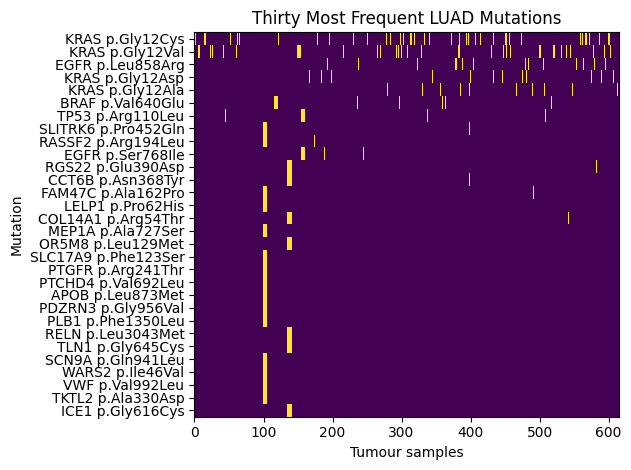

<Figure size 640x480 with 0 Axes>

In [8]:

sample_columns = result.columns[3:]

top_mutations = (
    result
    .assign(Mutation_Frequency=result[sample_columns].sum(axis=1))
    .sort_values("Mutation_Frequency", ascending=False)
    .head(30)
)


plt.imshow(top_mutations[sample_columns], aspect="auto", interpolation="nearest")
plt.yticks(
    range(len(top_mutations)),
    top_mutations["Gene_Name"] + " " + top_mutations["AminoAcid_Change"]
)
plt.xlabel("Tumour samples")
plt.ylabel("Mutation")
plt.title("Thirty Most Frequent LUAD Mutations")
plt.tight_layout()
plt.show()


plt.savefig("130heatmap.png")

Gene_Name
TTN      254
MUC16    231
CSMD3    204
RYR2     199
TP53     186
LRP1B    185
ZFHX4    171
USH2A    169
KRAS     158
XIRP2    134
dtype: int64


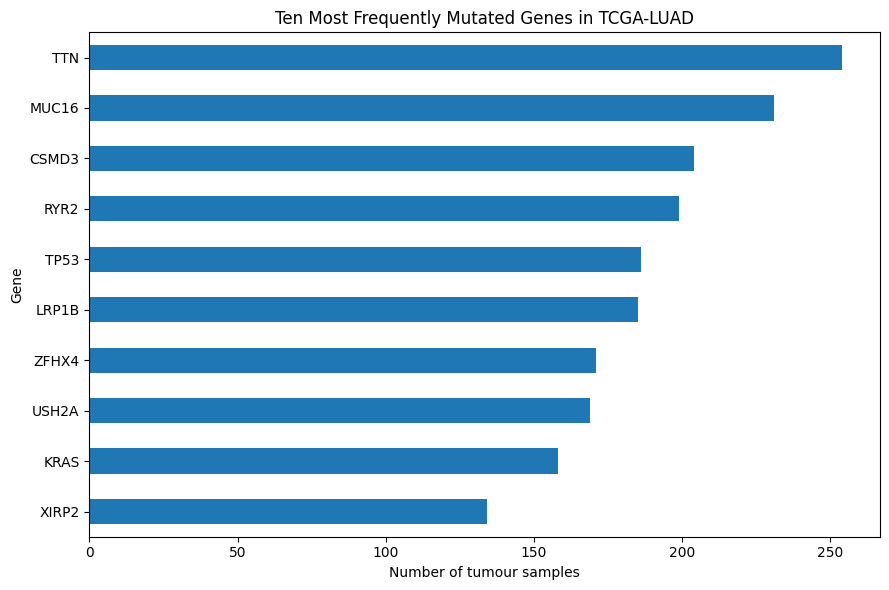

In [9]:
sample_columns = result.columns[3:]

# Collapse separate mutation rows into one row per gene.
# max() means that if any mutation in a gene is present in a sample,
# that gene is counted as mutated once in that sample.
gene_by_sample = (
    result
    .groupby("Gene_Name")[sample_columns]
    .max()
)

# Count the number of tumour samples mutated for each gene
gene_frequency = (
    gene_by_sample
    .sum(axis=1)
    .sort_values(ascending=False)
)

# Select the ten most frequently mutated genes
top_10_genes = gene_frequency.head(10)

print(top_10_genes)

# Create the bar plot
plt.figure(figsize=(9, 6))
top_10_genes.sort_values().plot(kind="barh")

plt.xlabel("Number of tumour samples")
plt.ylabel("Gene")
plt.title("Ten Most Frequently Mutated Genes in TCGA-LUAD")
plt.tight_layout()
plt.show()
